# Online Order - SQL data connection, data exploration, data export

In [44]:
from sqlalchemy import create_engine, text
import pandas as pd
import matplotlib.pyplot as plt

### SQL connection

In [45]:
# Define database credentials
userid = 'pythonuser1'
password = 'Passw0rd01!' #key in the password
host = '127.0.0.1' # Using IP 127.0.0.1
port = 3306
database = 'retail_sales_database' # Name of the target database

In [46]:
connection_string = f"mysql+pymysql://{userid}:{password}@{host}:{port}/{database}"

try:
    engine = create_engine(connection_string)
    # Testing the connection
    with engine.connect() as connection: # Properly opens/closes connection
        result = connection.execute(text("SELECT CURRENT_USER()"))
        print(f"Connected as: {result.fetchone()[0]}")
        # online store orders
        rs_onlstore = connection.execute("SELECT * FROM `online-store-orders`")
        df_onlstore = pd.DataFrame(rs_onlstore.fetchall())
except Exception as ex:
    print("Connection failed:", ex)

Connected as: pythonuser1@localhost


In [47]:
df_onlstore.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [48]:
df_onlstore['TotalPrice_computed'] = round(df_onlstore['Quantity'] * df_onlstore['UnitPrice'],2) 

In [49]:
df_onlstore.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,TotalPrice_computed
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,2504.04


In [50]:
df_onlstore['Total_same'] = df_onlstore['TotalPrice'] == df_onlstore['TotalPrice_computed']
# check if there are any data that has differences
print(df_onlstore['Total_same'].value_counts())

Total_same
True    1200
Name: count, dtype: int64


Check the unique value of OrderStatus

In [51]:
print(df_onlstore['OrderStatus'].unique())

['Shipped' 'Cancelled' 'Returned' 'Delivered' 'Pending']


Check the unique value of Product

In [71]:
print(df_onlstore['Product'].unique())

['Monitor' 'Phone' 'Tablet' 'Chair' 'Printer' 'Laptop' 'Desk']


Check if there are any Nulls or NAN

In [52]:
onlhasnulls = df_onlstore.isna().any().any()

In [53]:
print(onlhasnulls)

False


In [54]:
onlhasnulls = df_onlstore.isnull().any().any()

In [55]:
print(onlhasnulls)

False


Findings: Data is clean.

### Display Price total per Order status for 2025, arrange bin based on preferred sequence of status

In [69]:
#Prepare the data to be grouped and displayed only for year 2025
df_onlstore['Date'] = pd.to_datetime(df_onlstore['Date'])
df_date25 = df_onlstore[df_onlstore['Date'].dt.year == 2025]

#Convert Order status into a categorical data so it can be arranged based on preferred status
custom_order = ['Delivered', 'Shipped', 'Pending', 'Returned', 'Cancelled']
df_date25['OrderStatus'] = pd.Categorical(df_date25['OrderStatus'], categories=custom_order, ordered=True)

status_totals = df_date25.groupby('OrderStatus')['TotalPrice'].sum().reset_index()

C:\Users\Clifford\AppData\Local\Temp\ipykernel_81640\4033597225.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_date25['OrderStatus'] = pd.Categorical(df_date25['OrderStatus'], categories=custom_order, ordered=True)


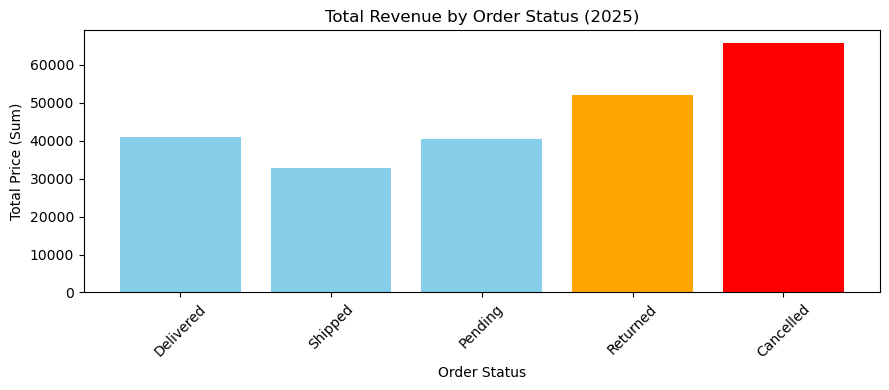

In [83]:
plt.figure(figsize=(9,4))

# Change the color for cancelled as this is not included in the sales
colors = ['red' if status == 'Cancelled' else 'orange' if status == 'Returned' else 'skyblue' 
          for status in status_totals['OrderStatus']]


plt.bar(status_totals['OrderStatus'], status_totals['TotalPrice'], color=colors)

plt.xlabel('Order Status')
plt.ylabel('Total Price (Sum)')
plt.title('Total Revenue by Order Status (2025)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Findings: there is a high rate of Cancelled and Returned orders

# Display Total Sales by Product

In [77]:
#Prepare the data to be grouped and displayed only for year 2025
df_onlstore['Date'] = pd.to_datetime(df_onlstore['Date'])
df_date25 = df_onlstore[df_onlstore['Date'].dt.year == 2025]
df_sales = df_date25[df_date25['OrderStatus'].isin(['Delivered', 'Shipped', 'Pending'])]


product_totals = df_sales.groupby('Product')['TotalPrice'].sum().reset_index()
product_totals = product_totals.sort_values('TotalPrice', ascending=False)


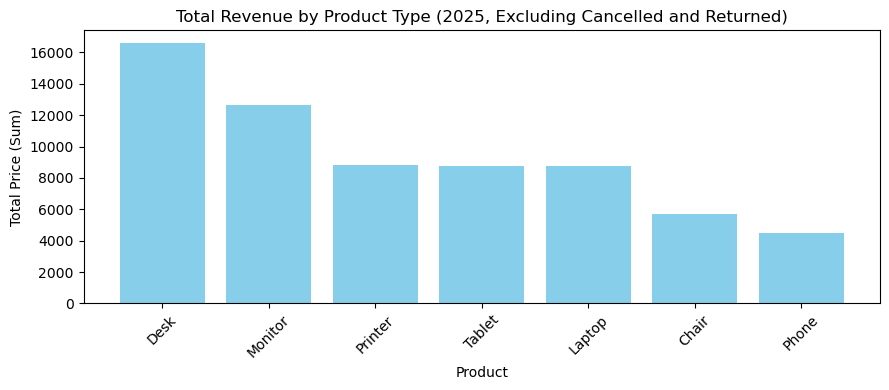

In [82]:
plt.figure(figsize=(9,4))
plt.bar(product_totals['Product'], product_totals['TotalPrice'], color='skyblue')

plt.xlabel('Product')
plt.ylabel('Total Price (Sum)')
plt.title('Total Revenue by Product Type (2025, Excluding Cancelled and Returned)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Display Cancelled sales by Product

In [80]:
#Prepare the data to be grouped and displayed only for year 2025
df_onlstore['Date'] = pd.to_datetime(df_onlstore['Date'])
df_date25 = df_onlstore[df_onlstore['Date'].dt.year == 2025]
df_sales = df_date25[df_date25['OrderStatus'].isin(['Cancelled'])]


product_totals = df_sales.groupby('Product')['TotalPrice'].sum().reset_index()
product_totals = product_totals.sort_values('TotalPrice', ascending=False)

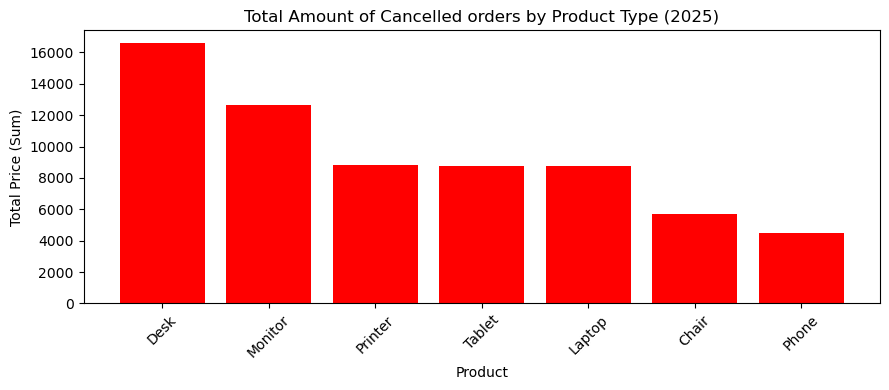

In [85]:
plt.figure(figsize=(9,4))
plt.bar(product_totals['Product'], product_totals['TotalPrice'], color='red')

plt.xlabel('Product')
plt.ylabel('Total Price (Sum)')
plt.title('Total Amount of Cancelled orders by Product Type (2025)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Display Returned orders by Product Type

In [86]:
#Prepare the data to be grouped and displayed only for year 2025
df_onlstore['Date'] = pd.to_datetime(df_onlstore['Date'])
df_date25 = df_onlstore[df_onlstore['Date'].dt.year == 2025]
df_sales = df_date25[df_date25['OrderStatus'].isin(['Returned'])]


product_totals = df_sales.groupby('Product')['TotalPrice'].sum().reset_index()
product_totals = product_totals.sort_values('TotalPrice', ascending=False)

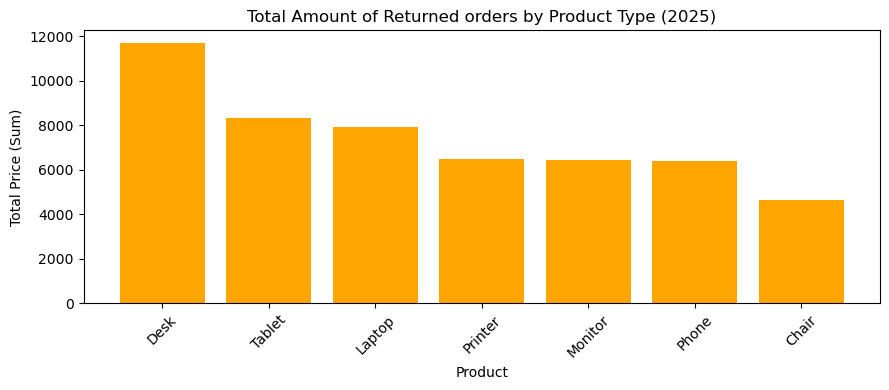

In [87]:
plt.figure(figsize=(9,4))
plt.bar(product_totals['Product'], product_totals['TotalPrice'], color='orange')

plt.xlabel('Product')
plt.ylabel('Total Price (Sum)')
plt.title('Total Amount of Returned orders by Product Type (2025)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Findings: Rate of returned and cancelled orders is consistent for desks

In [88]:
#Prepare the data to be grouped and displayed only for year 2025
df_onlstore['Date'] = pd.to_datetime(df_onlstore['Date'])
df_date25 = df_onlstore[df_onlstore['Date'].dt.year == 2025]

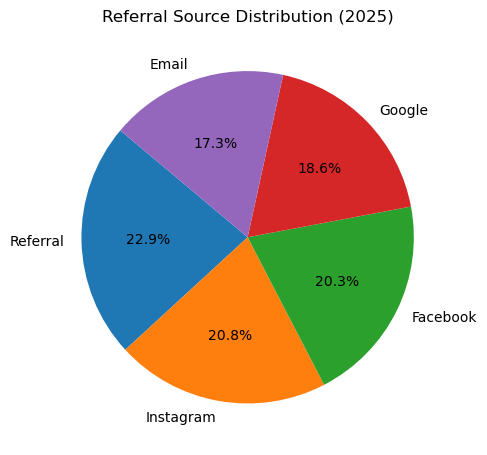

In [90]:
# Group by ReferralSource
ref_counts = df_date25['ReferralSource'].value_counts()

# Plot pie chart
plt.figure(figsize=(5,5))
plt.pie(ref_counts, labels=ref_counts.index, autopct='%1.1f%%', startangle=140)

plt.title('Referral Source Distribution (2025)')
plt.tight_layout()
plt.show()

Findings: Social Media is the driving force for online orders which contributes to combined 41.1% 

# Data Clean and import - drop unwanted columns and export csv

In [92]:
cols_to_drop = [
    'OrderID',
    'Quantity',
    'UnitPrice',
    'TrackingNumber',
    'ItemsInCart',
    'TotalPrice_Computed',
    'Total_Same'
]

df_clean = df_onlstore.drop(columns=cols_to_drop, errors='ignore')

In [93]:
#export to csv
df_clean.to_csv('online_store_orders_cleaned.csv', index=False)